In [1]:
ls -d /home/jovyan/scratch/eds/*/


/home/jovyan/scratch/eds/compat//   /home/jovyan/scratch/eds/results//
/home/jovyan/scratch/eds/queries//  /home/jovyan/scratch/eds/tiles//


In [2]:
# Cell 1 — Config
from pathlib import Path

ROOTS = [
    Path("/home/jovyan/scratch/eds/compat"),
    Path("/home/jovyan/scratch/eds/results"),
    Path("/home/jovyan/scratch/eds/queries"),
    Path("/home/jovyan/scratch/eds/tiles"),
]

MAX_DEPTH = 7         # how deep to walk under each root
MAX_FILES_PER_DIR = 5000  # safety limit per directory listing
FOLLOW_SYMLINKS = False


In [3]:
# Cell 2 — Helpers
import os
from collections import Counter, defaultdict
import pandas as pd

def _depth(rel_path: Path) -> int:
    if rel_path == Path("."):
        return 0
    return len(rel_path.parts)

def scan_root(root: Path, max_depth: int = 3, max_files_per_dir: int = 5000, follow_symlinks: bool = False):
    """
    Walk a directory tree and return:
      - overall summary
      - per-directory summary (within depth)
      - extension stats
    """
    root = root.resolve()
    if not root.exists():
        return None

    total_files = 0
    total_dirs = 0
    total_bytes = 0

    per_dir_rows = []
    ext_counts = Counter()
    ext_bytes = Counter()

    # os.walk is fast and stable on big trees; we limit depth ourselves.
    for dirpath, dirnames, filenames in os.walk(root, followlinks=follow_symlinks):
        dpath = Path(dirpath)
        rel = dpath.relative_to(root)
        d = _depth(rel)

        # prune traversal if deeper than max_depth
        if d >= max_depth:
            dirnames[:] = []  # stop going deeper

        # safety limit
        if len(filenames) > max_files_per_dir:
            filenames = filenames[:max_files_per_dir]

        # count directories (this one + children tracked via walk)
        total_dirs += 1

        # directory-level stats
        n_files = 0
        n_dirs = len(dirnames)
        bytes_here = 0

        for fn in filenames:
            fpath = dpath / fn
            try:
                if fpath.is_file():
                    n_files += 1
                    total_files += 1
                    sz = fpath.stat().st_size
                    bytes_here += sz
                    total_bytes += sz

                    ext = fpath.suffix.lower() if fpath.suffix else "<no_ext>"
                    ext_counts[ext] += 1
                    ext_bytes[ext] += sz
            except (FileNotFoundError, PermissionError):
                # file disappeared mid-walk or permission issue — ignore
                continue

        per_dir_rows.append({
            "root": str(root),
            "rel_dir": str(rel),
            "depth": d,
            "subdirs": n_dirs,
            "files": n_files,
            "bytes": bytes_here
        })

    summary = {
        "root": str(root),
        "exists": True,
        "dirs_scanned": total_dirs,
        "files_scanned": total_files,
        "total_bytes": total_bytes,
    }

    per_dir_df = pd.DataFrame(per_dir_rows).sort_values(["depth", "rel_dir"]).reset_index(drop=True)

    ext_df = (
        pd.DataFrame({
            "ext": list(ext_counts.keys()),
            "files": list(ext_counts.values()),
            "bytes": [ext_bytes[e] for e in ext_counts.keys()],
        })
        .sort_values(["bytes", "files"], ascending=False)
        .reset_index(drop=True)
    )

    return summary, per_dir_df, ext_df

def human_bytes(n: int) -> str:
    units = ["B","KB","MB","GB","TB","PB"]
    n = float(n)
    for u in units:
        if n < 1024 or u == units[-1]:
            return f"{n:.2f} {u}"
        n /= 1024


In [4]:
# Cell 3 — Run scan
results = []

for root in ROOTS:
    out = scan_root(
        root,
        max_depth=MAX_DEPTH,
        max_files_per_dir=MAX_FILES_PER_DIR,
        follow_symlinks=FOLLOW_SYMLINKS,
    )
    if out is None:
        results.append(({"root": str(root), "exists": False}, None, None))
    else:
        results.append(out)

# High-level summary table
summary_df = pd.DataFrame([r[0] for r in results])
summary_df["total_size"] = summary_df["total_bytes"].fillna(0).astype("int64").apply(human_bytes)
summary_df


,root,exists,dirs_scanned,files_scanned,total_bytes,total_size
0,/home/jovyan/scratch/eds/compat,True,166,15783,312308921062,290.86 GB
1,/home/jovyan/scratch/eds/results,True,4,577,11521414566,10.73 GB
2,/home/jovyan/scratch/eds/queries,True,28,343,14912606,14.22 MB
3,/home/jovyan/scratch/eds/tiles,True,8044,26545,19111434199557,17.38 TB


## Lsat tiles

In [5]:
# Cell 4 — Show per-root “what’s in what” (top subfolders)
# This aggregates immediate children (depth 1) so you can see how each root is structured.

subfolder_rows = []

for (summary, per_dir_df, ext_df) in results:
    if per_dir_df is None:
        continue

    root = summary["root"]
    # depth=1 folders: rel_dir like "p089r078" or "p089r078/sr" depending on root
    d1 = per_dir_df[per_dir_df["depth"] == 1].copy()

    # If there are no depth-1 dirs (empty root), include a placeholder row
    if d1.empty:
        subfolder_rows.append({"root": root, "subfolder": "<empty>", "files": 0, "size": "0 B"})
        continue

    for _, row in d1.iterrows():
        subfolder_rows.append({
            "root": root,
            "subfolder": row["rel_dir"],
            "files": int(row["files"]),
            "size": human_bytes(int(row["bytes"]))
        })

subfolders_df = pd.DataFrame(subfolder_rows).sort_values(["root", "subfolder"]).reset_index(drop=True)
subfolders_df


,root,subfolder,files,size
0,/home/jovyan/scratch/eds/compat,.ipynb_checkpoints,0,0.00 B
1,/home/jovyan/scratch/eds/compat,files,0,0.00 B
2,/home/jovyan/scratch/eds/queries,2015112820251128,4,172.28 KB
3,/home/jovyan/scratch/eds/queries,2015113020251130,6,260.74 KB
4,/home/jovyan/scratch/eds/queries,2015120120251201,6,240.02 KB
...,...,...,...,...
63,/home/jovyan/scratch/eds/tiles,p104r070,0,0.00 B
64,/home/jovyan/scratch/eds/tiles,p104r071,0,0.00 B
65,/home/jovyan/scratch/eds/tiles,p104r072,0,0.00 B
66,/home/jovyan/scratch/eds/tiles,p104r074,0,0.00 B


In [6]:
import pandas as pd
from pathlib import Path

# Find the scan result for the tiles root
tiles_root = "/home/jovyan/scratch/eds/tiles"
tiles_result = None
for (summary, per_dir_df, ext_df) in results:
    if summary["root"] == tiles_root:
        tiles_result = (summary, per_dir_df, ext_df)
        break

if tiles_result is None:
    raise RuntimeError("tiles root not found in results")

summary, per_dir_df, ext_df = tiles_result

# The first path element under tiles is the "tile prefix" (e.g. p090r088)
per_dir_df = per_dir_df.copy()
per_dir_df["tile"] = per_dir_df["rel_dir"].apply(lambda s: Path(s).parts[0] if s != "." else "<root>")

# Sum everything under each tile (recursive within your scan depth)
tile_totals = (
    per_dir_df[per_dir_df["tile"] != "<root>"]
    .groupby("tile", as_index=False)
    .agg(
        dirs=("rel_dir", "count"),
        files=("files", "sum"),
        bytes=("bytes", "sum"),
        max_depth=("depth", "max"),
    )
    .sort_values(["files", "bytes"], ascending=False)
    .reset_index(drop=True)
)

tile_totals["size"] = tile_totals["bytes"].astype("int64").apply(human_bytes)
tile_totals


,tile,dirs,files,bytes,max_depth,size
0,p095r081,346,1652,1066228145523,4,993.00 GB
1,p095r080,352,1638,1059299809110,4,986.55 GB
2,p094r084,355,1386,915330890665,4,852.47 GB
3,p094r073,361,1358,833166604785,4,775.95 GB
4,p095r079,310,1300,841906889267,4,784.09 GB
5,p094r085,331,1246,820940318740,4,764.56 GB
6,p093r085,337,1239,816648492358,4,760.56 GB
7,p104r074,373,1215,1073843995113,4,1000.10 GB
8,p095r072,322,1113,680709041134,4,633.96 GB
9,p108r081,355,1098,956990386214,4,891.27 GB


In [7]:
from pathlib import Path

def top2_parts(rel_dir: str):
    parts = Path(rel_dir).parts
    if rel_dir == ".":
        return ("<root>", "<root>")
    if len(parts) == 1:
        return (parts[0], "<none>")
    return (parts[0], parts[1])

tmp = per_dir_df.copy()
tmp[["tile", "cat"]] = tmp["rel_dir"].apply(lambda s: pd.Series(top2_parts(s)))

# only keep categories we care about
tmp["cat"] = tmp["cat"].where(tmp["cat"].isin(["sr", "fc"]), other="other")

tile_cat = (
    tmp[tmp["tile"] != "<root>"]
    .groupby(["tile", "cat"], as_index=False)
    .agg(files=("files", "sum"), bytes=("bytes", "sum"))
)

pivot = (
    tile_cat.pivot(index="tile", columns="cat", values=["files", "bytes"])
    .fillna(0)
)

# flatten columns
pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
pivot = pivot.reset_index()

# add totals
pivot["files_total"] = pivot.get("files_sr", 0) + pivot.get("files_fc", 0) + pivot.get("files_other", 0)
pivot["bytes_total"] = pivot.get("bytes_sr", 0) + pivot.get("bytes_fc", 0) + pivot.get("bytes_other", 0)
pivot["size_total"] = pivot["bytes_total"].astype("int64").apply(human_bytes)

pivot = pivot.sort_values(["files_total", "bytes_total"], ascending=False).reset_index(drop=True)
pivot


,tile,files_fc,files_other,files_sr,bytes_fc,bytes_other,bytes_sr,files_total,bytes_total,size_total
0,p095r081,708,236,708,421230546050,13172388616,631825210857,1652,1066228145523,993.00 GB
1,p095r080,702,234,702,418493390164,13086784152,627719634794,1638,1059299809110,986.55 GB
2,p094r084,594,198,594,361616120694,11308092840,542406677131,1386,915330890665,852.47 GB
3,p094r073,582,194,582,329155921358,10293252776,493717430651,1358,833166604785,775.95 GB
4,p095r079,556,186,558,332067356172,10412127480,499427405615,1300,841906889267,784.09 GB
5,p094r085,534,178,534,324325619674,10141992508,486472706558,1246,820940318740,764.56 GB
6,p093r085,531,177,531,322630064038,10088969025,483929459295,1239,816648492358,760.56 GB
7,p104r074,486,243,486,424236347856,13266917667,636340729590,1215,1073843995113,1000.10 GB
8,p095r072,477,159,477,268925104218,8409745002,403374191914,1113,680709041134,633.96 GB
9,p108r081,440,218,440,378071823720,11823224768,567095337726,1098,956990386214,891.27 GB


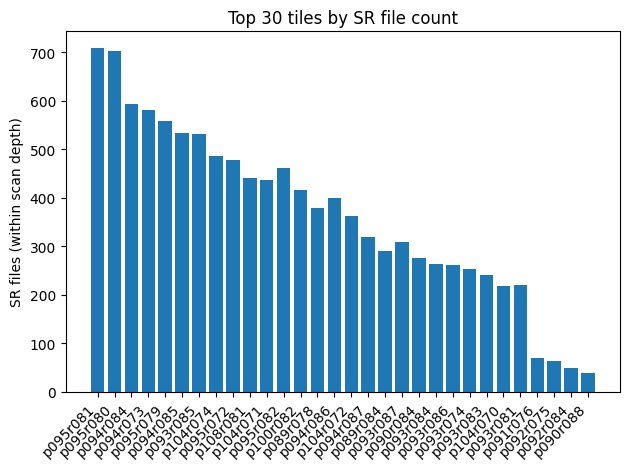

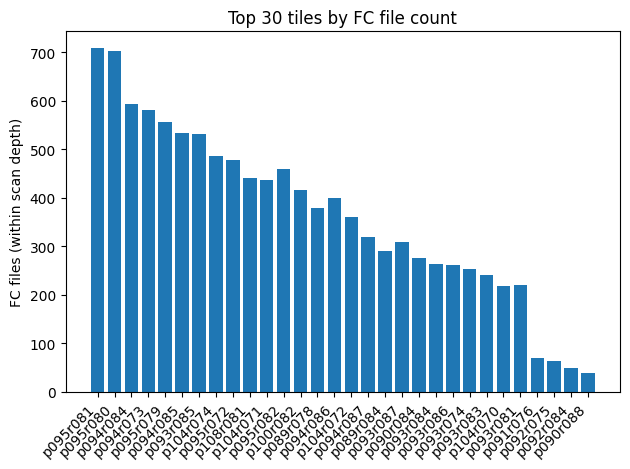

In [8]:
import matplotlib.pyplot as plt
import numpy as np

df = pivot.copy()

# keep top N to avoid unreadable charts
TOPN = 30
df = df.head(TOPN)

x = np.arange(len(df["tile"]))

plt.figure()
plt.bar(x, df.get("files_sr", 0))
plt.xticks(x, df["tile"], rotation=45, ha="right")
plt.ylabel("SR files (within scan depth)")
plt.title(f"Top {TOPN} tiles by SR file count")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(x, df.get("files_fc", 0))
plt.xticks(x, df["tile"], rotation=45, ha="right")
plt.ylabel("FC files (within scan depth)")
plt.title(f"Top {TOPN} tiles by FC file count")
plt.tight_layout()
plt.show()


## Visualise Lsat tile

In [9]:
from pathlib import Path

DIR = Path("/home/jovyan/scratch/eds/tiles/p092r088")

for p in sorted(DIR.rglob("*")):
    if p.is_file():
        print(p)


/home/jovyan/scratch/eds/tiles/p092r088/fc/2023/202304/galsfc3_p092r088_20230413_fcm5.tif
/home/jovyan/scratch/eds/tiles/p092r088/fc/2023/202304/galsfc3_p092r088_20230413_fcm5_clr.tif
/home/jovyan/scratch/eds/tiles/p092r088/fc/2023/202304/galsfc3_p092r088_20230413_fcm5_clr.tif.metadata.json
/home/jovyan/scratch/eds/tiles/p092r088/fc/2023/202304/galsfc3_p092r088_20230429_fcm5.tif
/home/jovyan/scratch/eds/tiles/p092r088/fc/2023/202304/galsfc3_p092r088_20230429_fcm5_clr.tif
/home/jovyan/scratch/eds/tiles/p092r088/fc/2023/202304/galsfc3_p092r088_20230429_fcm5_clr.tif.metadata.json
/home/jovyan/scratch/eds/tiles/p092r088/fc/2023/202305/galsfc3_p092r088_20230507_fcm5.tif
/home/jovyan/scratch/eds/tiles/p092r088/fc/2023/202305/galsfc3_p092r088_20230507_fcm5_clr.tif
/home/jovyan/scratch/eds/tiles/p092r088/fc/2023/202305/galsfc3_p092r088_20230507_fcm5_clr.tif.metadata.json
/home/jovyan/scratch/eds/tiles/p092r088/fc/2023/202305/galsfc3_p092r088_20230515_fcm5.tif
/home/jovyan/scratch/eds/tiles/p09

In [10]:
from pathlib import Path
import re
import pandas as pd

TILE_DIR = Path("/home/jovyan/scratch/eds/tiles/p092r088")  # <-- change tile here
PRODUCTS = ["fc", "sr", "ffmask"]  # add/remove as needed

date_re = re.compile(r"(19|20)\d{6}")

rows = []
for prod in PRODUCTS:
    base = TILE_DIR / prod
    if not base.exists():
        continue
    for p in base.rglob("*"):
        if not p.is_file():
            continue
        m = date_re.search(p.name)
        if not m:
            continue
        yyyymmdd = m.group(0)
        rows.append({
            "tile": TILE_DIR.name,
            "product": prod,
            "path": str(p),
            "date": yyyymmdd,
            "year": int(yyyymmdd[:4]),
            "month": int(yyyymmdd[4:6]),
            "yyyymm": yyyymmdd[:6],
        })

df = pd.DataFrame(rows)
if df.empty:
    print("No dated files found under:", TILE_DIR)
else:
    df["date_dt"] = pd.to_datetime(df["date"], format="%Y%m%d")
    df


In [11]:
if df.empty:
    pass
else:
    summary = (
        df.groupby("product")
        .agg(
            files=("path", "count"),
            first_date=("date_dt", "min"),
            last_date=("date_dt", "max"),
            min_year=("year", "min"),
            max_year=("year", "max"),
            unique_months=("yyyymm", "nunique"),
        )
        .reset_index()
    )

    summary["year_span"] = summary["min_year"].astype(str) + "–" + summary["max_year"].astype(str)
    summary


In [12]:
if df.empty:
    pass
else:
    # overall months present (ignoring year)
    overall_months = (
        df.groupby(["product", "month"])
        .size()
        .reset_index(name="files")
        .sort_values(["product", "month"])
    )

    # by year-month
    year_month = (
        df.groupby(["product", "year", "month"])
        .size()
        .reset_index(name="files")
        .sort_values(["product", "year", "month"])
    )

    print("Overall months present (by product):")
    display(overall_months)

    print("\nYear-month coverage (by product):")
    display(year_month)


Overall months present (by product):


,product,month,files
0,fc,4,6
1,fc,5,6
2,fc,6,3
3,fc,7,3
4,fc,8,3
5,ffmask,4,2
6,ffmask,5,2
7,ffmask,6,1
8,ffmask,7,1
9,ffmask,8,1



Year-month coverage (by product):


,product,year,month,files
0,fc,2023,4,6
1,fc,2023,5,6
2,fc,2023,6,3
3,fc,2023,7,3
4,fc,2023,8,3
5,ffmask,2023,4,2
6,ffmask,2023,5,2
7,ffmask,2023,6,1
8,ffmask,2023,7,1
9,ffmask,2023,8,1


In [13]:
if df.empty:
    pass
else:
    heat = (
        df.groupby(["product", "year", "month"])
        .size()
        .reset_index(name="files")
        .pivot_table(index=["product", "year"], columns="month", values="files", fill_value=0)
        .sort_index()
    )
    heat


In [14]:
from IPython.display import display

# If you already created `heat`
print(heat.to_string())


month           4    5    6    7    8
product year                         
fc      2023  6.0  6.0  3.0  3.0  3.0
ffmask  2023  2.0  2.0  1.0  1.0  1.0
sr      2023  6.0  6.0  3.0  3.0  3.0


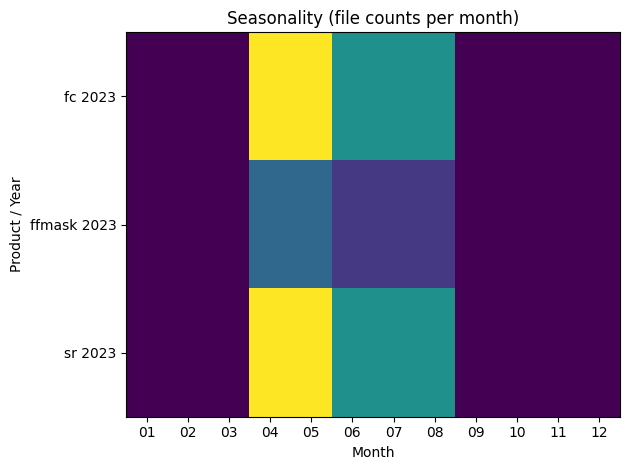

In [15]:
import numpy as np
import matplotlib.pyplot as plt

heat = (
    df.groupby(["product", "year", "month"])
      .size()
      .reset_index(name="files")
      .pivot_table(index=["product", "year"], columns="month", values="files", fill_value=0)
      .sort_index()
)
heat = heat.reindex(columns=range(1, 13), fill_value=0)

arr = heat.to_numpy()

plt.figure()
plt.imshow(arr, aspect="auto")  # no custom colours
plt.yticks(np.arange(len(heat.index)), [f"{p} {y}" for (p, y) in heat.index])
plt.xticks(np.arange(12), [str(m).zfill(2) for m in range(1, 13)])
plt.xlabel("Month")
plt.ylabel("Product / Year")
plt.title("Seasonality (file counts per month)")
plt.tight_layout()
plt.show()


In [16]:
from pathlib import Path
import re
import pandas as pd

TILES_ROOT = Path("/home/jovyan/scratch/eds/tiles")
PRODUCT = "fc"  # change to sr / ffmask as needed

date_re = re.compile(r"(19|20)\d{6}")
rows = []

for tile_dir in sorted([p for p in TILES_ROOT.iterdir() if p.is_dir() and p.name.startswith("p")]):
    base = tile_dir / PRODUCT
    if not base.exists():
        continue

    for p in base.rglob("*"):
        if not p.is_file():
            continue
        m = date_re.search(p.name)
        if not m:
            continue
        yyyymmdd = m.group(0)
        rows.append({
            "tile": tile_dir.name,
            "product": PRODUCT,
            "date": yyyymmdd,
            "year": int(yyyymmdd[:4]),
            "month": int(yyyymmdd[4:6]),
        })

df_all = pd.DataFrame(rows)
if df_all.empty:
    print("No dated files found.")
else:
    df_all["date_dt"] = pd.to_datetime(df_all["date"], format="%Y%m%d")

    tile_cov = (
        df_all.groupby("tile")
        .agg(
            files=("date", "count"),
            first=("date_dt", "min"),
            last=("date_dt", "max"),
            min_year=("year", "min"),
            max_year=("year", "max"),
            unique_months=("month", "nunique"),
        )
        .reset_index()
        .sort_values(["min_year", "files"], ascending=[True, False])
    )
    tile_cov["year_span"] = tile_cov["min_year"].astype(str) + "–" + tile_cov["max_year"].astype(str)
    tile_cov


In [17]:
from IPython.display import display
display(tile_cov)


,tile,files,first,last,min_year,max_year,unique_months,year_span
37,p104r074,486,2015-12-23,2025-10-31,2015,2025,12,2015–2025
38,p108r081,440,2015-12-19,2025-12-22,2015,2025,12,2015–2025
35,p104r071,436,2015-12-07,2025-10-31,2015,2025,11,2015–2025
33,p100r082,416,2015-12-27,2025-11-12,2015,2025,12,2015–2025
0,p089r078,378,2015-12-13,2025-11-14,2015,2025,12,2015–2025
36,p104r072,361,2015-12-07,2025-02-01,2015,2025,12,2015–2025
1,p089r084,290,2015-12-13,2025-10-13,2015,2025,12,2015–2025
34,p104r070,217,2015-12-07,2025-10-31,2015,2025,9,2015–2025
31,p095r081,708,2016-02-10,2025-12-27,2016,2025,11,2016–2025
30,p095r080,702,2016-02-10,2025-12-27,2016,2025,11,2016–2025


## 1–12 counts per tile

In [18]:
# Deduplicate to 1 record per tile per acquisition date
dfu = df_all.drop_duplicates(["tile", "date"]).copy()

# ---- base summary (what you already have) ----
tile_base = (
    dfu.groupby("tile")
    .agg(
        files=("date", "count"),
        first=("date_dt", "min"),
        last=("date_dt", "max"),
        min_year=("year", "min"),
        max_year=("year", "max"),
        unique_months=("month", "nunique"),
    )
)

tile_base["year_span"] = (
    tile_base["min_year"].astype(str) + "–" + tile_base["max_year"].astype(str)
)

# ---- month counts (1–12) ----
month_counts = (
    dfu.groupby(["tile", "month"])
       .size()
       .unstack(fill_value=0)
)

# Ensure all 12 months exist as columns
month_counts = month_counts.reindex(columns=range(1, 13), fill_value=0)

# Rename columns to m01–m12 (clean + sortable)
month_counts.columns = [f"m{m:02d}" for m in month_counts.columns]

# ---- combine ----
tile_cov = (
    tile_base
    .join(month_counts)
    .reset_index()
    .sort_values(["min_year", "files"], ascending=[True, False])
)

from IPython.display import display
display(tile_cov)


,tile,files,first,last,min_year,max_year,unique_months,year_span,m01,m02,m03,m04,m05,m06,m07,m08,m09,m10,m11,m12
37,p104r074,243,2015-12-23,2025-10-31,2015,2025,12,2015–2025,8,16,20,24,24,21,26,27,22,23,13,19
38,p108r081,218,2015-12-19,2025-12-22,2015,2025,12,2015–2025,21,17,19,15,21,9,21,16,23,17,17,22
35,p104r071,216,2015-12-07,2025-10-31,2015,2025,11,2015–2025,4,0,16,21,25,23,25,24,24,25,13,16
33,p100r082,208,2015-12-27,2025-11-12,2015,2025,12,2015–2025,18,18,21,16,20,15,17,15,21,16,15,16
0,p089r078,189,2015-12-13,2025-11-14,2015,2025,12,2015–2025,18,11,11,18,16,20,16,24,16,17,10,12
36,p104r072,181,2015-12-07,2025-02-01,2015,2025,12,2015–2025,7,9,16,17,19,18,16,18,18,17,10,16
1,p089r084,145,2015-12-13,2025-10-13,2015,2025,12,2015–2025,12,10,12,14,13,8,17,14,15,8,8,14
34,p104r070,93,2015-12-07,2025-10-31,2015,2025,9,2015–2025,5,0,0,0,3,4,3,3,22,25,15,13
31,p095r081,236,2016-02-10,2025-12-27,2016,2025,11,2016–2025,0,24,24,21,21,18,21,26,24,17,17,23
30,p095r080,234,2016-02-10,2025-12-27,2016,2025,11,2016–2025,0,23,21,20,22,18,20,24,24,17,21,24


# ------------------------------------ results -------------------------------------

In [19]:
from pathlib import Path

RESULTS_ROOT = Path("/home/jovyan/scratch/eds/results")

MAX_DEPTH = 6          # deep enough for EDS outputs
MAX_FILES_PER_DIR = 5000


In [20]:
import os
import pandas as pd
from collections import Counter

rows = []
ext_counts = Counter()
ext_bytes = Counter()

total_files = 0
total_bytes = 0

for dirpath, dirnames, filenames in os.walk(RESULTS_ROOT):
    dpath = Path(dirpath)
    rel = dpath.relative_to(RESULTS_ROOT)
    depth = len(rel.parts) if rel != Path(".") else 0

    if depth > MAX_DEPTH:
        dirnames[:] = []
        continue

    for fn in filenames[:MAX_FILES_PER_DIR]:
        fpath = dpath / fn
        if not fpath.is_file():
            continue

        try:
            size = fpath.stat().st_size
        except FileNotFoundError:
            continue

        total_files += 1
        total_bytes += size

        ext = fpath.suffix.lower() if fpath.suffix else "<no_ext>"
        ext_counts[ext] += 1
        ext_bytes[ext] += size

        rows.append({
            "rel_dir": str(rel),
            "depth": depth,
            "file": fn,
            "ext": ext,
            "bytes": size,
        })

df = pd.DataFrame(rows)

print(f"Scanned files: {total_files}")
print(f"Total size: {total_bytes / 1024 / 1024 / 1024:.2f} GB")


Scanned files: 577
Total size: 10.73 GB


In [21]:
summary = (
    df.groupby("rel_dir")
      .agg(
          files=("file", "count"),
          bytes=("bytes", "sum"),
      )
      .reset_index()
      .sort_values("bytes", ascending=False)
)

summary["size"] = summary["bytes"] / 1024 / 1024
summary.head(20)


,rel_dir,files,bytes,size
0,fpc/p089r078,577,11521414566,10987.67716


In [22]:
top_level = summary[summary["rel_dir"].str.count("/") == 0].copy()
top_level[["rel_dir", "files", "size"]]


,rel_dir,files,size


In [23]:
ext_df = pd.DataFrame({
    "extension": list(ext_counts.keys()),
    "files": list(ext_counts.values()),
    "bytes": [ext_bytes[e] for e in ext_counts.keys()],
})

ext_df["size_mb"] = ext_df["bytes"] / 1024 / 1024
ext_df.sort_values("size_mb", ascending=False)


,extension,files,bytes,size_mb
1,.img,192,11521113720,10987.390251
0,.hdr,192,150985,0.143991
2,.xml,192,103700,0.098896
3,.json,1,46161,0.044023


In [24]:
from pathlib import Path

df["prefix"] = df["rel_dir"].apply(
    lambda s: Path(s).parts[0] if s != "." else "<root>"
)

prefix_totals = (
    df[df["prefix"] != "<root>"]
    .groupby("prefix")
    .agg(
        files=("file", "count"),
        bytes=("bytes", "sum"),
    )
    .reset_index()
    .sort_values("bytes", ascending=False)
)

prefix_totals["size_gb"] = prefix_totals["bytes"] / 1024 / 1024 / 1024
prefix_totals


,prefix,files,bytes,size_gb
0,fpc,577,11521414566,10.730153


# --------------------------------------- compat ---------------------------------------

In [25]:
from pathlib import Path

COMPAT_ROOT = Path("/home/jovyan/scratch/eds/compat")

MAX_DEPTH = 6          # deep enough for EDS outputs
MAX_FILES_PER_DIR = 5000


In [26]:
import os
import pandas as pd
from collections import Counter

rows = []
ext_counts = Counter()
ext_bytes = Counter()

total_files = 0
total_bytes = 0

for dirpath, dirnames, filenames in os.walk(COMPAT_ROOT):
    dpath = Path(dirpath)
    rel = dpath.relative_to(COMPAT_ROOT)
    depth = len(rel.parts) if rel != Path(".") else 0

    if depth > MAX_DEPTH:
        dirnames[:] = []
        continue

    for fn in filenames[:MAX_FILES_PER_DIR]:
        fpath = dpath / fn
        if not fpath.is_file():
            continue

        try:
            size = fpath.stat().st_size
        except FileNotFoundError:
            continue

        total_files += 1
        total_bytes += size

        ext = fpath.suffix.lower() if fpath.suffix else "<no_ext>"
        ext_counts[ext] += 1
        ext_bytes[ext] += size

        rows.append({
            "rel_dir": str(rel),
            "depth": depth,
            "file": fn,
            "ext": ext,
            "bytes": size,
        })

df = pd.DataFrame(rows)

print(f"Scanned files: {total_files}")
print(f"Total size: {total_bytes / 1024 / 1024 / 1024:.2f} GB")


Scanned files: 15783
Total size: 290.86 GB


In [27]:
summary = (
    df.groupby("rel_dir")
      .agg(
          files=("file", "count"),
          bytes=("bytes", "sum"),
      )
      .reset_index()
      .sort_values("bytes", ascending=False)
)

summary["size"] = summary["bytes"] / 1024 / 1024
summary.head(20)


,rel_dir,files,bytes,size
56,files/fc/p104r074,746,14893530795,14203.577800
59,files/fc/p108r081,671,13440106387,12817.484271
44,files/fc/p094r084,611,13011782406,12409.002691
50,files/fc/p100r082,641,12941984976,12342.438675
41,files/fc/p094r073,596,11822878867,11275.175921
62,files/fpc/p089r078,584,11790617163,11244.408763
0,files/fc/p089r078,584,11790599187,11244.391620
23,files/fc/p093r085,548,11790203378,11244.014147
139,files/ndvi/p104r074,530,10965569828,10457.582310
127,files/ndvi/p095r079,497,10628293270,10135.930319


In [28]:
from pathlib import Path

RESULTS_ROOT = Path("/home/jovyan/scratch/eds/compat")
TARGET_REL = Path("files/ndvi/p089r084")

EXTS = {".tif", ".tiff", ".img", ".shp"}


In [29]:
base_dir = RESULTS_ROOT / TARGET_REL

if not base_dir.exists():
    raise FileNotFoundError(base_dir)

for p in sorted(base_dir.rglob("*")):
    if p.is_file() and p.suffix.lower() in EXTS:
        rel_folder = p.parent.relative_to(base_dir)
        print(f"{p}  |  folder: {rel_folder}")


/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/diagnostics/lztmre_p089r084_20230125_combined_raw.img  |  folder: diagnostics
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmna_p089r084_eall_dw1mz.img  |  folder: .
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20151213_dc4ndvi.img  |  folder: .
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20151229_dc4ndvi.img  |  folder: .
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160130_dc4ndvi.img  |  folder: .
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160215_dc4ndvi.img  |  folder: .
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160302_dc4ndvi.img  |  folder: .
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160318_dc4ndvi.img  |  folder: .
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160419_dc4ndvi.img  |  folder: .
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/

In [30]:
from collections import defaultdict

groups = defaultdict(list)

for p in base_dir.rglob("*"):
    if p.is_file() and p.suffix.lower() in EXTS:
        subdir = p.parent.relative_to(base_dir)
        groups[str(subdir)].append(p)

for subdir, files in sorted(groups.items()):
    print("\n" + "="*80)
    print(f"SUBDIR: {subdir}")
    print("="*80)
    for f in sorted(files):
        print(f)



SUBDIR: .
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmna_p089r084_eall_dw1mz.img
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20151213_dc4ndvi.img
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20151229_dc4ndvi.img
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160130_dc4ndvi.img
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160215_dc4ndvi.img
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160302_dc4ndvi.img
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160318_dc4ndvi.img
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160419_dc4ndvi.img
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160505_dc4ndvi.img
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160521_dc4ndvi.img
/home/jovyan/scratch/eds/compat/files/ndvi/p089r084/lztmre_p089r084_20160724_dc4ndvi.img
/home/jovyan/scr